# Phase 4 — MA-BBOB Instance Selection (K=20)

Select 20 training instances from the 1000-instance MA-BBOB pool, optimising **per-function uniformity** (low CV across all 24 BBOB functions). Compares against the Phase 1 selection (K=10) and the full pool.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

weights = pd.read_csv("../BLADE/iohblade/benchmarks/BBOB/mabbob/weights.csv", index_col=0)
W = weights.values  # 1000 x 24

GROUPS = {
    "Separable (f1-f5)": list(range(0, 5)),
    "Low/mod conditioning (f6-f9)": list(range(5, 9)),
    "High cond / unimodal (f10-f14)": list(range(9, 14)),
    "Multimodal adequate (f15-f19)": list(range(14, 19)),
    "Multimodal weak (f20-f24)": list(range(19, 24)),
}

func_labels = [f"f{i+1}" for i in range(24)]
group_map = {}
for gname, cols in GROUPS.items():
    for c in cols:
        group_map[func_labels[c]] = gname.split(" (")[0]

group_colors = {
    "Separable": "#4e79a7",
    "Low/mod conditioning": "#f28e2b",
    "High cond / unimodal": "#e15759",
    "Multimodal adequate": "#76b7b2",
    "Multimodal weak": "#59a14f",
}
bar_colors = [group_colors[group_map[f]] for f in func_labels]

# Phase 1 selection (K=10)
P1_INDICES = [191, 277, 300, 412, 455, 635, 648, 744, 760, 843]

# Phase 4 selection (K=20) — from analysis/select_instances_phase4.py
# Greedy + simulated annealing (20 restarts x 100k iter) + local search
P4_INDICES = [35, 48, 50, 288, 396, 445, 514, 590, 605, 642,
              680, 721, 725, 770, 780, 805, 816, 831, 916, 968]

print(f"Pool: {W.shape[0]} instances, {W.shape[1]} BBOB functions")
print(f"Phase 1: {len(P1_INDICES)} instances")
print(f"Phase 4: {len(P4_INDICES)} instances")

Pool: 1000 instances, 24 BBOB functions
Phase 1: 10 instances
Phase 4: 20 instances


## Per-instance weight breakdown

In [2]:
detail = pd.DataFrame(W[P4_INDICES], index=P4_INDICES, columns=func_labels)
detail.index.name = "Instance"
detail_display = detail.replace(0, np.nan)

styled = (
    detail_display.style
    .format("{:.1%}", na_rep=".")
    .background_gradient(cmap="YlOrRd", axis=None, vmin=0, vmax=0.3)
)
styled

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24
Instance,,,,,,,,,,,,,,,,,,,,,,,,
35,.,34.0%,.,1.5%,.,7.8%,.,.,.,.,.,.,37.2%,.,.,.,.,.,.,19.4%,.,.,.,.
48,.,.,.,.,.,.,.,.,50.3%,.,29.5%,.,.,20.2%,.,.,.,.,.,.,.,.,.,.
50,.,.,.,.,.,34.6%,34.1%,31.3%,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.
288,.,.,.,22.8%,.,.,6.7%,.,.,27.0%,7.4%,.,.,.,.,.,.,.,.,.,28.8%,.,7.3%,.
396,41.3%,30.3%,.,.,.,.,.,.,.,.,.,.,.,.,.,15.0%,.,.,.,.,.,.,.,13.4%
445,10.2%,.,.,.,.,29.3%,14.8%,.,.,.,.,.,.,.,.,.,.,15.3%,.,.,.,.,.,30.4%
514,.,.,2.8%,.,.,.,19.3%,.,3.3%,.,7.2%,.,.,.,.,.,.,2.4%,31.2%,27.1%,.,.,.,6.6%
590,.,.,23.0%,.,.,.,.,.,30.5%,.,.,.,.,.,.,33.7%,.,.,.,.,.,.,.,12.8%
605,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,58.1%,.,.,41.9%,.,.,.


## Per-function coverage summary

In [3]:
p4_sub = W[P4_INDICES]
p4_totals = p4_sub.sum(axis=0)
p4_counts = (p4_sub > 0).sum(axis=0)
p4_total = p4_totals.sum()

func_summary = pd.DataFrame({
    "Function": func_labels,
    "# Instances": p4_counts,
    "Weight sum": p4_totals,
    "Share": p4_totals / p4_total,
}).set_index("Function")

func_summary["Group"] = func_summary.index.map(group_map)
func_summary.style.format({"Weight sum": "{:.3f}", "Share": "{:.1%}"})

,# Instances,Weight sum,Share,Group
Function,,,,
f1,3,0.718,3.6%,Separable
f2,5,0.800,4.0%,Separable
f3,4,0.785,3.9%,Separable
f4,7,0.903,4.5%,Separable
f5,2,0.801,4.0%,Separable
f6,4,0.878,4.4%,Low/mod conditioning
f7,5,0.891,4.5%,Low/mod conditioning
f8,3,0.783,3.9%,Low/mod conditioning
f9,3,0.840,4.2%,Low/mod conditioning


## Group balance

In [4]:
group_data = []
for gname, cols in GROUPS.items():
    gweight = p4_totals[cols].sum()
    group_data.append({
        "Group": gname,
        "Weight sum": gweight,
        "Share": gweight / p4_total,
        "Deviation from 20%": gweight / p4_total - 0.2,
    })

group_df = pd.DataFrame(group_data).set_index("Group")
group_df.style.format({"Weight sum": "{:.3f}", "Share": "{:.1%}", "Deviation from 20%": "{:+.1%}"})

,Weight sum,Share,Deviation from 20%
Group,,,
Separable (f1-f5),4.007,20.0%,+0.0%
Low/mod conditioning (f6-f9),3.393,17.0%,-3.0%
High cond / unimodal (f10-f14),3.971,19.9%,-0.1%
Multimodal adequate (f15-f19),4.410,22.0%,+2.0%
Multimodal weak (f20-f24),4.218,21.1%,+1.1%


## Per-function weight distribution

How evenly is each BBOB function's total weight distributed across the 20 selected instances? The ideal share per function is 1/24 = 4.2%.

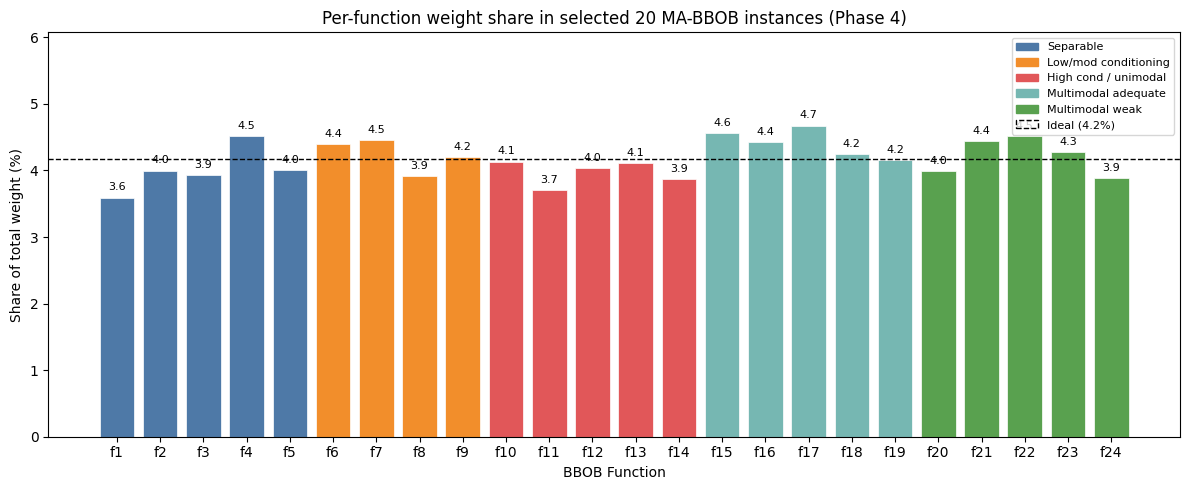

Per-function share: min=3.6%, max=4.7%, mean=4.2%, std=0.3%
Coefficient of variation: 0.067 (0 = perfectly uniform)


In [5]:
ideal = 1.0 / 24
p4_shares = p4_totals / p4_total

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(func_labels, p4_shares * 100, color=bar_colors, edgecolor="white", linewidth=0.5)
ax.axhline(y=ideal * 100, color="black", linestyle="--", linewidth=1, label=f"Ideal ({ideal*100:.1f}%)")
ax.set_ylabel("Share of total weight (%)")
ax.set_xlabel("BBOB Function")
ax.set_title("Per-function weight share in selected 20 MA-BBOB instances (Phase 4)")
ax.set_ylim(0, max(p4_shares * 100) * 1.3)

for bar, share in zip(bars, p4_shares):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.08,
            f"{share*100:.1f}", ha="center", va="bottom", fontsize=8)

patches = [mpatches.Patch(color=c, label=g) for g, c in group_colors.items()]
patches.append(mpatches.Patch(facecolor="none", edgecolor="black", linestyle="--", label="Ideal (4.2%)"))
ax.legend(handles=patches, loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

print(f"Per-function share: min={p4_shares.min()*100:.1f}%, max={p4_shares.max()*100:.1f}%, "
      f"mean={p4_shares.mean()*100:.1f}%, std={p4_shares.std()*100:.1f}%")
print(f"Coefficient of variation: {p4_shares.std()/p4_shares.mean():.3f} (0 = perfectly uniform)")

## Group balance bar chart

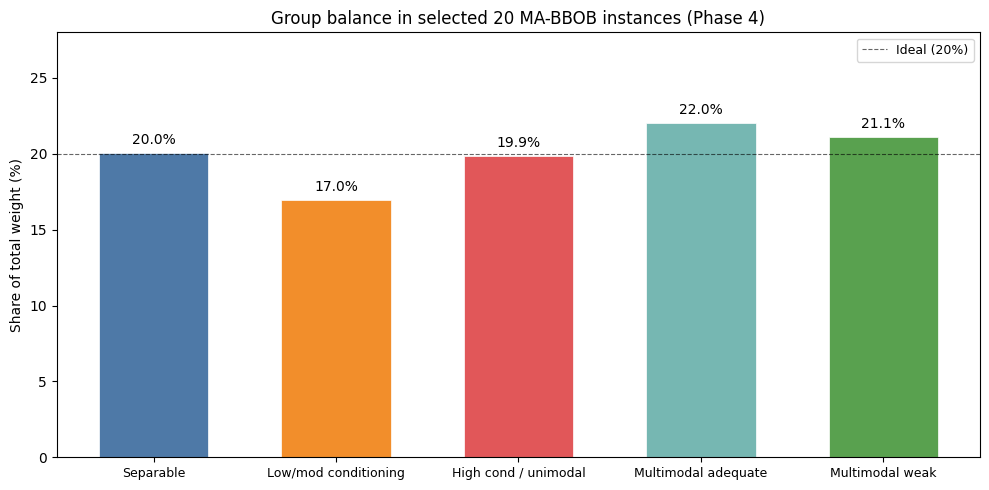

In [6]:
group_names_short = [g.split(" (")[0] for g in GROUPS.keys()]
group_cols_list = list(GROUPS.values())
p4_group_shares = [p4_totals[cols].sum() / p4_total for cols in group_cols_list]

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(group_names_short))
colors = list(group_colors.values())

bars = ax.bar(x, [s * 100 for s in p4_group_shares], color=colors,
              edgecolor="white", linewidth=0.5, width=0.6)
ax.axhline(y=20, color="black", linestyle="--", linewidth=0.8, alpha=0.6, label="Ideal (20%)")

ax.set_ylabel("Share of total weight (%)")
ax.set_xticks(x)
ax.set_xticklabels(group_names_short, fontsize=9)
ax.set_title("Group balance in selected 20 MA-BBOB instances (Phase 4)")
ax.set_ylim(0, 28)

for bar, share in zip(bars, p4_group_shares):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f"{share*100:.1f}%", ha="center", va="bottom", fontsize=10)

ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Per-function comparison: Phase 1 (K=10) vs Phase 4 (K=20) vs Full pool

/var/folders/jr/n9z3k78146x3z51srj3w4g3c0000gn/T/ipykernel_27592/3850860925.py:31: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color="#d4d4d4", edgecolor="grey", label="Phase 1 (K=10)"),


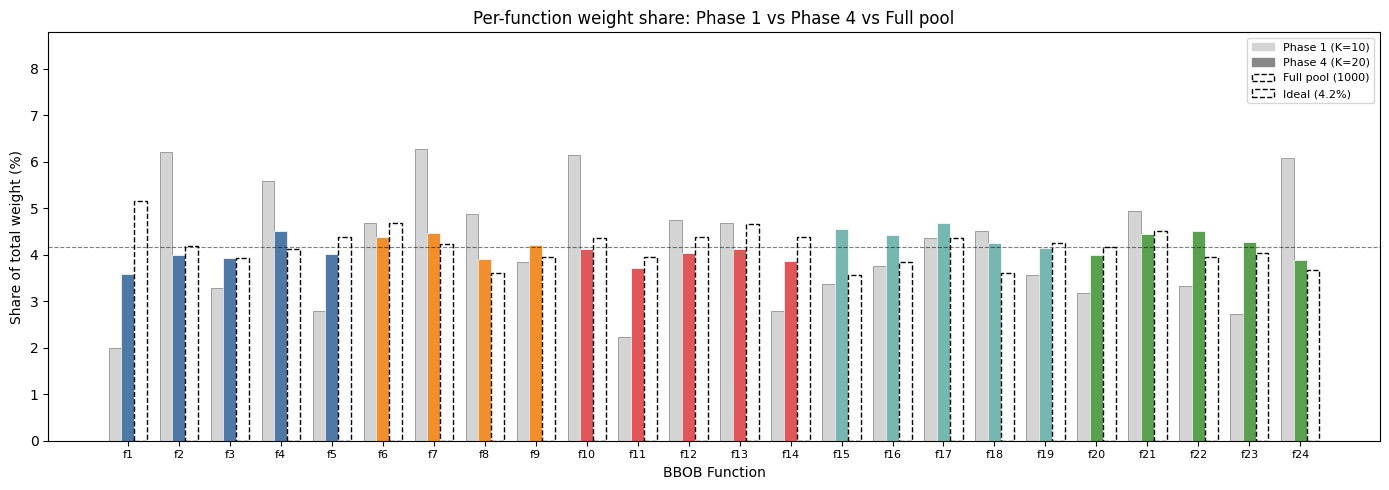

                Phase 1    Phase 4       Pool
          CV      0.304      0.067      0.090
   Min share       2.0%       3.6%       3.6%
   Max share       6.3%       4.7%       5.2%

CV = coefficient of variation (lower = more uniform)


In [7]:
p1_sub = W[P1_INDICES]
p1_totals = p1_sub.sum(axis=0)
p1_total = p1_totals.sum()
p1_shares = p1_totals / p1_total

pool_totals = W.sum(axis=0)
pool_shares = pool_totals / pool_totals.sum()

x = np.arange(24)
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))

bars_p1 = ax.bar(x - width, p1_shares * 100, width,
                 label="Phase 1 (K=10)", color="#d4d4d4", edgecolor="grey", linewidth=0.5)
bars_p4 = ax.bar(x, p4_shares * 100, width,
                 label="Phase 4 (K=20)", color=bar_colors, edgecolor="white", linewidth=0.5)
bars_pool = ax.bar(x + width, pool_shares * 100, width,
                   label="Full pool (1000)", color="white",
                   edgecolor="black", linewidth=1, linestyle="--")

ax.axhline(y=ideal * 100, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_ylabel("Share of total weight (%)")
ax.set_xlabel("BBOB Function")
ax.set_xticks(x)
ax.set_xticklabels(func_labels, fontsize=8)
ax.set_title("Per-function weight share: Phase 1 vs Phase 4 vs Full pool")
ax.set_ylim(0, max(p1_shares.max(), p4_shares.max(), pool_shares.max()) * 100 * 1.4)

patches = [
    mpatches.Patch(color="#d4d4d4", edgecolor="grey", label="Phase 1 (K=10)"),
    mpatches.Patch(color="#888888", label="Phase 4 (K=20)"),
    mpatches.Patch(facecolor="white", edgecolor="black", linestyle="--", label="Full pool (1000)"),
    mpatches.Patch(facecolor="none", edgecolor="black", linestyle="--", label=f"Ideal ({ideal*100:.1f}%)"),
]
ax.legend(handles=patches, loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

# Summary comparison
p1_cv = p1_shares.std() / p1_shares.mean()
p4_cv = p4_shares.std() / p4_shares.mean()
pool_cv = pool_shares.std() / pool_shares.mean()

print(f"{'':>12} {'Phase 1':>10} {'Phase 4':>10} {'Pool':>10}")
print(f"{'CV':>12} {p1_cv:>10.3f} {p4_cv:>10.3f} {pool_cv:>10.3f}")
print(f"{'Min share':>12} {p1_shares.min()*100:>9.1f}% {p4_shares.min()*100:>9.1f}% {pool_shares.min()*100:>9.1f}%")
print(f"{'Max share':>12} {p1_shares.max()*100:>9.1f}% {p4_shares.max()*100:>9.1f}% {pool_shares.max()*100:>9.1f}%")
print(f"\nCV = coefficient of variation (lower = more uniform)")

## Group comparison: Phase 1 vs Phase 4 vs Full pool

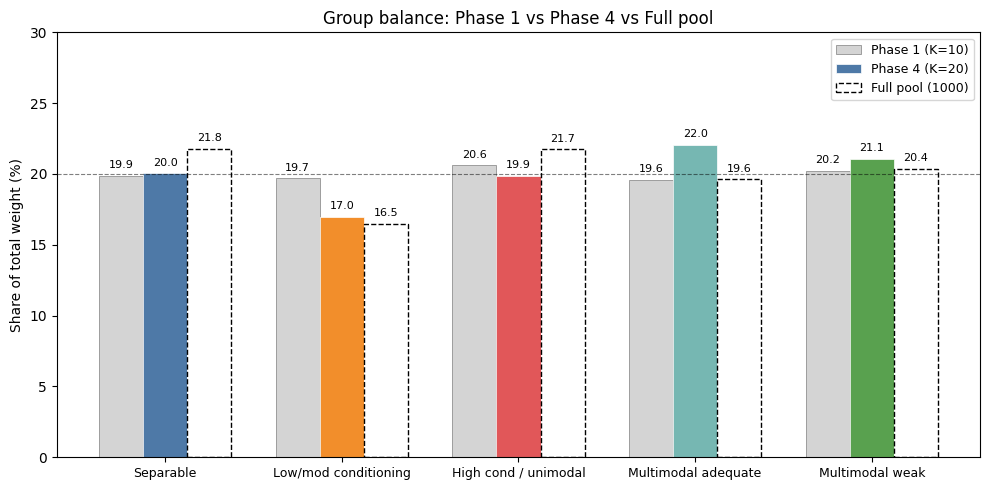

In [8]:
p1_group_shares = [p1_totals[cols].sum() / p1_total for cols in group_cols_list]
pool_group_shares = [W[:, cols].sum() / W.sum() for cols in group_cols_list]

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(group_names_short))
width = 0.25

bars_p1 = ax.bar(x - width, [s * 100 for s in p1_group_shares],
                 width, label="Phase 1 (K=10)", color="#d4d4d4", edgecolor="grey", linewidth=0.5)
bars_p4 = ax.bar(x, [s * 100 for s in p4_group_shares],
                 width, label="Phase 4 (K=20)", color=colors,
                 edgecolor="white", linewidth=0.5)
bars_pool = ax.bar(x + width, [s * 100 for s in pool_group_shares],
                   width, label="Full pool (1000)", color="white",
                   edgecolor="black", linewidth=1, linestyle="--")

ax.axhline(y=20, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_ylabel("Share of total weight (%)")
ax.set_xticks(x)
ax.set_xticklabels(group_names_short, fontsize=9)
ax.set_title("Group balance: Phase 1 vs Phase 4 vs Full pool")
ax.set_ylim(0, 30)

for barset in [bars_p1, bars_p4, bars_pool]:
    for bar in barset:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.4,
                f"{h:.1f}", ha="center", va="bottom", fontsize=8)

ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Instance overlap between Phase 1 and Phase 4

In [9]:
overlap = set(P1_INDICES) & set(P4_INDICES)
p1_only = sorted(set(P1_INDICES) - set(P4_INDICES))
p4_only = sorted(set(P4_INDICES) - set(P1_INDICES))

print(f"Phase 1 instances: {P1_INDICES}")
print(f"Phase 4 instances: {P4_INDICES}")
print(f"\nOverlap ({len(overlap)}): {sorted(overlap)}")
print(f"Phase 1 only ({len(p1_only)}): {p1_only}")
print(f"Phase 4 only ({len(p4_only)}): {p4_only}")

Phase 1 instances: [191, 277, 300, 412, 455, 635, 648, 744, 760, 843]
Phase 4 instances: [35, 48, 50, 288, 396, 445, 514, 590, 605, 642, 680, 721, 725, 770, 780, 805, 816, 831, 916, 968]

Overlap (0): []
Phase 1 only (10): [191, 277, 300, 412, 455, 635, 648, 744, 760, 843]
Phase 4 only (20): [35, 48, 50, 288, 396, 445, 514, 590, 605, 642, 680, 721, 725, 770, 780, 805, 816, 831, 916, 968]
